In [2]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import openml
import pandas as pd
import ipywidgets as widgets
from tqdm import tqdm

from IPython.display import display, clear_output

from datasets import (
    preprocess_features,
    encode_and_scale_features,
    download_and_process_dataset,
    download_benchmark_suite,
    download_datasets_from_df
)

from qualities import extract_suite_qualities, get_missing_data_summary

from d2v_qualities import (
    extract_metafeatures_from_datasets,
    combine_metafeature_files,
    extract_and_combine_metafeatures
)

from runs import (run_extract_runs_for_suite, debug_suite_tasks)

from meta_learning_evaluation import run_complete_evaluation, load_target_data, plot_results

### Establish the benchmark suites 
1. Download datasets
2. Download openml qualities (dealing with missing information ???)

In [5]:
selected_suite_id = None


suites_df = openml.study.list_suites(output_format="dataframe", status="all")
suites_df["alias"] = suites_df["alias"].fillna("unnamed")


options = [(f"{alias} ({sid})", sid) for sid, alias in zip(suites_df["id"], suites_df["alias"])]


dropdown = widgets.Dropdown(
    options=options,
    description='Suite:',
    layout=widgets.Layout(width='70%')
)
output = widgets.Output()


def on_dropdown_change(change):
    global selected_suite_id
    if change['type'] == 'change' and change['name'] == 'value':
        with output:
            clear_output()
            selected_suite_id = change['new']
            selected_label = next(label for label, val in options if val == selected_suite_id)
            suite_alias = selected_label.split(' (')[0]

            print(f"Selected Suite: {suite_alias} ({selected_suite_id})")

            print("Downloading datasets...")
            results = download_benchmark_suite(selected_suite_id)
            print(f"Download complete: {results['successful']}/{results['total']} successful, {results['failed']} failed")

            print("\nExtracting qualities...")
            df = extract_suite_qualities(selected_suite_id)
            print(f"Qualities extraction finished: {len(df)} datasets processed")


dropdown.observe(on_dropdown_change)

KeyboardInterrupt: 

In [4]:
display(dropdown, output)

NameError: name 'dropdown' is not defined

### Creating d2v meta features

In [ ]:
combined_df = extract_and_combine_metafeatures()


### Fetching runs

In [ ]:
run_extract_runs_for_suite(selected_suite_id)

Majority Class: Support Vector Machine
Majority Class Accuracy (baseline): 53.70%
All files saved to: final
Meta-feature datasets loaded.
Shapes:
  - d2v: (54, 33)
  - traditional: (54, 94)
  - hybrid: (54, 126)

 Evaluating d2v meta-model ...
  Mean accuracy: 0.5796 ± 0.0263

 Evaluating hybrid meta-model ...
  Mean accuracy: 0.6574 ± 0.0344

 Evaluating traditional meta-model ...
  Mean accuracy: 0.6630 ± 0.0259


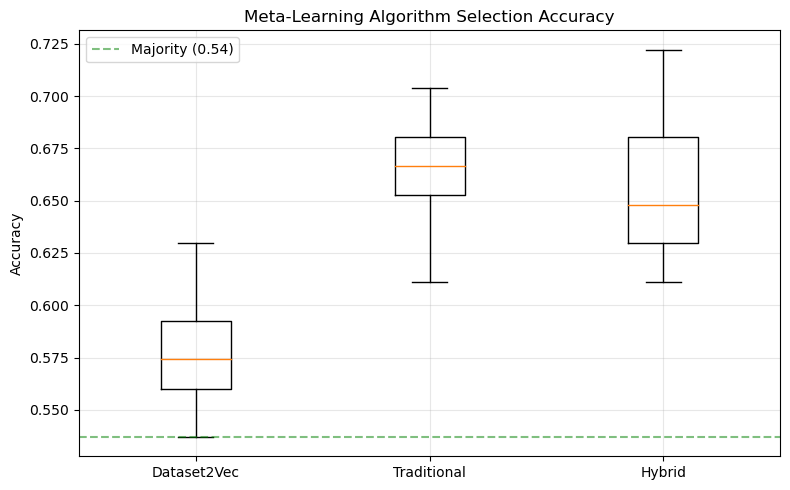

In [3]:
results, majority_accuracy = run_complete_evaluation(n_repeats=10, seed=175)